# Machine Learning Supervise — Classification multi-label des regimes alimentaires

**Objectif** : Entrainer un classifieur multi-label qui predit, a partir du profil nutritionnel d'un produit, sa compatibilite avec plusieurs regimes alimentaires simultanement (vegan, keto, sans gluten, etc.).

**Source des donnees** : MongoDB (collection `foodiz.products`, peuplee par le notebook [2-Pipeline_ETL](2-Pipeline_ETL.ipynb)).

**Labels a predire (9 flags de regime)** :
- `is_vegan`, `is_vegetarian`, `is_gluten_free`, `is_lactose_free`, `is_organic`
- `is_keto`, `is_low_carb`, `is_high_protein`, `is_low_sugar`

**Point important** : les flags `is_keto`, `is_low_carb`, `is_high_protein`, `is_low_sugar` sont des fonctions deterministes des valeurs nutritionnelles (definies par regles dans le pipeline ETL). Le modele devrait donc les predire quasi parfaitement — c'est un test de sanite du pipeline. En revanche, `is_vegan`, `is_vegetarian`, `is_gluten_free`, `is_lactose_free`, `is_organic` dependent des ingredients/labels textuels, **pas** des valeurs nutritionnelles utilisees comme features ici. Predire ces flags a partir du seul profil nutritionnel est un vrai defi de generalisation, et un score imparfait est attendu et informatif.

## 1. Imports et configuration

In [1]:
import time
import os
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pymongo import MongoClient

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    hamming_loss, accuracy_score, precision_score, recall_score,
    f1_score, multilabel_confusion_matrix
)

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

MONGO_URI = "mongodb://localhost:27017"
DB_NAME = "foodiz"
COLLECTION_NAME = "products"
RANDOM_STATE = 42
MAX_SAMPLES = 300_000

## 2. Chargement des donnees depuis MongoDB

On ne recupere que les champs necessaires (`nutrition`, `quality`, `meta.additives_count`, `regime`) via une projection, pour limiter le volume transfere.

In [2]:
client = MongoClient(MONGO_URI)
db = client[DB_NAME]
collection = db[COLLECTION_NAME]

projection = {
    '_id': 0,
    'code': 1,
    'product_name': 1,
    'main_category': 1,
    'nutrition': 1,
    'quality': 1,
    'meta.additives_count': 1,
    'regime': 1
}

t0 = time.time()
records = list(collection.find({}, projection))
df_raw = pd.json_normalize(records)
duree = time.time() - t0

print(f"Chargement MongoDB : {len(df_raw):,} documents en {duree:.1f}s")
print(f"Colonnes disponibles : {list(df_raw.columns)}")
df_raw.head(3)

Chargement MongoDB : 2,200,323 documents en 96.0s
Colonnes disponibles : ['code', 'product_name', 'main_category', 'nutrition.energy_kcal', 'nutrition.fat', 'nutrition.saturated_fat', 'nutrition.carbohydrates', 'nutrition.sugars', 'nutrition.fiber', 'nutrition.proteins', 'regime.is_vegan', 'regime.is_vegetarian', 'regime.is_gluten_free', 'regime.is_lactose_free', 'regime.is_keto', 'regime.is_low_carb', 'regime.is_high_protein', 'regime.is_low_sugar', 'regime.is_organic', 'meta.additives_count', 'nutrition.salt', 'nutrition.sodium', 'quality.nutriscore_grade', 'quality.nutriscore_score', 'quality.nova_group']


,code,product_name,main_category,nutrition.energy_kcal,nutrition.fat,nutrition.saturated_fat,nutrition.carbohydrates,nutrition.sugars,nutrition.fiber,nutrition.proteins,...,regime.is_low_carb,regime.is_high_protein,regime.is_low_sugar,regime.is_organic,meta.additives_count,nutrition.salt,nutrition.sodium,quality.nutriscore_grade,quality.nutriscore_score,quality.nova_group
0,1000.0,Pinto Bean,Asian-style-ready-meal,261.40,10.20,3.60,22.50,4.90,3.80,17.50,...,True,False,True,True,0,NaN,NaN,NaN,NaN,NaN
1,100000004.0,Croquetas de bacalao,NaN,204.90,12.10,3.40,18.10,1.90,NaN,5.90,...,True,False,True,False,0,0.70,0.28,NaN,NaN,NaN
2,100000150.0,Keto & GF Granola,NaN,580.65,54.84,16.13,19.35,3.23,9.68,19.68,...,True,False,True,False,0,0.52,0.21,NaN,NaN,NaN


## 3. Selection des features et des labels

In [3]:
feature_cols = [
    'nutrition.energy_kcal', 'nutrition.fat', 'nutrition.saturated_fat',
    'nutrition.carbohydrates', 'nutrition.sugars', 'nutrition.fiber',
    'nutrition.proteins', 'nutrition.salt', 'nutrition.sodium',
    'quality.nutriscore_score', 'quality.nova_group',
    'meta.additives_count'
]

label_cols = [
    'regime.is_vegan', 'regime.is_vegetarian', 'regime.is_gluten_free',
    'regime.is_lactose_free', 'regime.is_keto', 'regime.is_low_carb',
    'regime.is_high_protein', 'regime.is_low_sugar', 'regime.is_organic'
]

# Securite : ajoute les colonnes manquantes (si jamais aucun document ne les contient)
for col in feature_cols + label_cols:
    if col not in df_raw.columns:
        df_raw[col] = np.nan

for col in label_cols:
    df_raw[col] = df_raw[col].fillna(False).astype(int)

print(f"Features ({len(feature_cols)}) : {feature_cols}")
print(f"\nLabels ({len(label_cols)}) : {[c.replace('regime.', '') for c in label_cols]}")

Features (12) : ['nutrition.energy_kcal', 'nutrition.fat', 'nutrition.saturated_fat', 'nutrition.carbohydrates', 'nutrition.sugars', 'nutrition.fiber', 'nutrition.proteins', 'nutrition.salt', 'nutrition.sodium', 'quality.nutriscore_score', 'quality.nova_group', 'meta.additives_count']

Labels (9) : ['is_vegan', 'is_vegetarian', 'is_gluten_free', 'is_lactose_free', 'is_keto', 'is_low_carb', 'is_high_protein', 'is_low_sugar', 'is_organic']


## 4. Filtrage des produits avec donnees nutritionnelles fiables

Les flags `is_keto`, `is_low_carb`, `is_high_protein`, `is_low_sugar` dependent de `fat`, `carbohydrates`, `proteins`, `sugars`. Si ces valeurs sont manquantes, le flag a ete fixe a `False` par defaut dans le pipeline ETL (et non pas "inconnu"), ce qui introduirait du bruit dans les labels. On ne garde donc que les produits ou ces 4 nutriments sont renseignes.

In [4]:
required_nutrition = ['nutrition.fat', 'nutrition.carbohydrates', 'nutrition.proteins', 'nutrition.sugars']

n_before = len(df_raw)
df_ml = df_raw.dropna(subset=required_nutrition).copy()
n_after = len(df_ml)

print(f"Avant filtrage : {n_before:,} produits")
print(f"Apres filtrage : {n_after:,} produits ({n_after / n_before:.1%} conserves)")

if len(df_ml) > MAX_SAMPLES:
    df_ml = df_ml.sample(n=MAX_SAMPLES, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"Echantillonnage applique : {MAX_SAMPLES:,} produits conserves (pour limiter le temps d'entrainement)")

Avant filtrage : 2,200,323 produits
Apres filtrage : 2,082,840 produits (94.7% conserves)
Echantillonnage applique : 300,000 produits conserves (pour limiter le temps d'entrainement)


## 5. Distribution des labels (regime flags)

Verifier l'equilibre des classes — important pour interpreter les metriques (un flag rare necessite de regarder le recall, pas seulement l'accuracy).

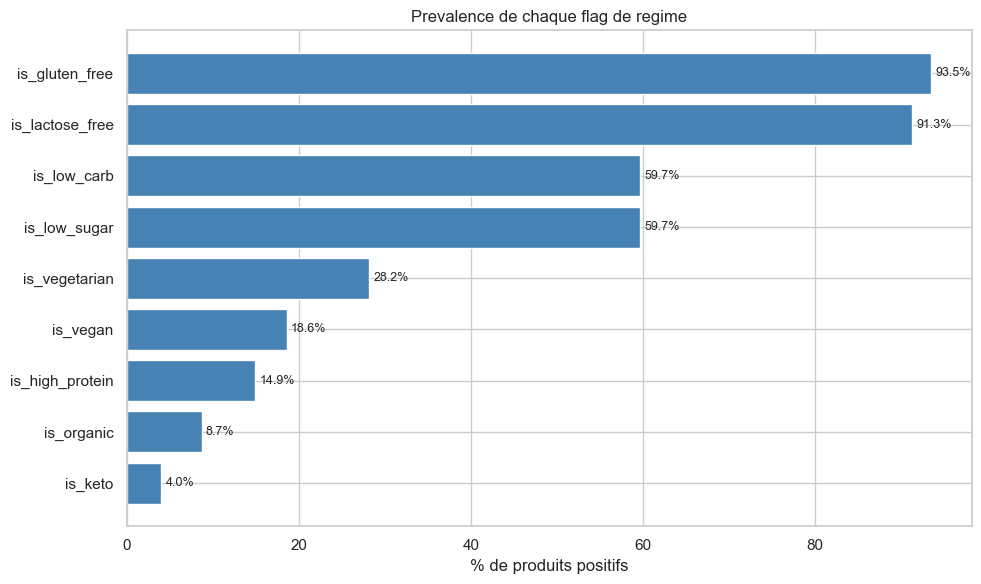

In [5]:
label_prevalence = (df_ml[label_cols].mean() * 100).sort_values(ascending=False)
label_prevalence.index = [c.replace('regime.', '') for c in label_prevalence.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(label_prevalence.index, label_prevalence.values, color='steelblue')
ax.set_xlabel('% de produits positifs')
ax.set_title('Prevalence de chaque flag de regime')
ax.invert_yaxis()
for bar, v in zip(bars, label_prevalence.values):
    ax.text(v + 0.5, bar.get_y() + bar.get_height() / 2, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Correlation entre les flags de regime

Certains flags sont logiquement lies (ex: vegan implique vegetarien).

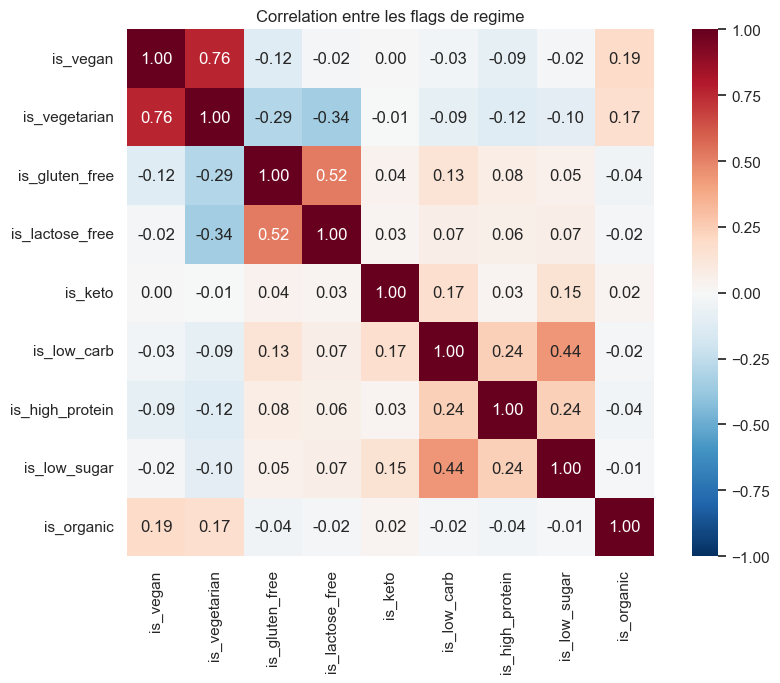

In [6]:
corr = df_ml[label_cols].corr()
corr.columns = corr.index = [c.replace('regime.', '') for c in corr.columns]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlation entre les flags de regime')
plt.tight_layout()
plt.show()

## 7. Preparation du jeu d'entrainement / test

In [7]:
X = df_ml[feature_cols].copy()
y = df_ml[label_cols].copy()
y.columns = [c.replace('regime.', '') for c in y.columns]

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X, y, df_ml[['code', 'product_name']],
    test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train : {X_train.shape[0]:,} produits")
print(f"Test  : {X_test.shape[0]:,} produits")
print(f"Features : {X_train.shape[1]} | Labels : {y_train.shape[1]}")

Train : 240,000 produits
Test  : 60,000 produits
Features : 12 | Labels : 9


## 8. Modele baseline — Regression logistique multi-label

`MultiOutputClassifier` entraine un classifieur binaire independant par label. Pipeline avec imputation (mediane) + standardisation, necessaire pour la regression logistique.

In [8]:
logreg_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', MultiOutputClassifier(
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
    ))
])

t0 = time.time()
logreg_pipeline.fit(X_train, y_train)
train_time_logreg = time.time() - t0

t0 = time.time()
y_pred_logreg = logreg_pipeline.predict(X_test)
predict_time_logreg = time.time() - t0

print(f"Regression logistique — entrainement : {train_time_logreg:.1f}s | inference test : {predict_time_logreg:.2f}s "
      f"({len(X_test) / predict_time_logreg:,.0f} produits/s)")

Regression logistique — entrainement : 3.8s | inference test : 0.04s (1,649,601 produits/s)


## 9. Modele — Random Forest multi-label

Capture les relations non lineaires entre nutriments (utile car les seuils de regime comme le keto sont des regles non lineaires).

In [9]:
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=200, max_depth=15, min_samples_leaf=5,
            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
        )
    ))
])

t0 = time.time()
rf_pipeline.fit(X_train, y_train)
train_time_rf = time.time() - t0

t0 = time.time()
y_pred_rf = rf_pipeline.predict(X_test)
predict_time_rf = time.time() - t0

print(f"Random Forest — entrainement : {train_time_rf:.1f}s | inference test : {predict_time_rf:.2f}s "
      f"({len(X_test) / predict_time_rf:,.0f} produits/s)")

Random Forest — entrainement : 65.5s | inference test : 1.60s (37,611 produits/s)


## 10. Comparaison des modeles

**Metriques multi-label :**
- **Hamming loss** : taux d'erreur moyen par label (plus bas = mieux)
- **Exact match ratio** : % de produits ou les 9 labels sont tous corrects simultanement (tres strict)
- **Precision / Recall / F1 par label** : pour identifier les regimes bien/mal predits

In [10]:
def global_metrics(y_true, y_pred, model_name):
    return {
        'model': model_name,
        'hamming_loss': hamming_loss(y_true, y_pred),
        'exact_match_ratio': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_micro': f1_score(y_true, y_pred, average='micro', zero_division=0),
    }

global_df = pd.DataFrame([
    global_metrics(y_test, y_pred_logreg, 'Regression logistique'),
    global_metrics(y_test, y_pred_rf, 'Random Forest'),
]).set_index('model')

global_df

,hamming_loss,exact_match_ratio,f1_macro,f1_micro
model,,,,
Regression logistique,0.113489,0.476683,0.790845,0.864783
Random Forest,0.066991,0.630933,0.859430,0.919792


In [11]:
def per_label_metrics(y_true, y_pred, label_names, model_name):
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    rows = []
    for i, label in enumerate(label_names):
        rows.append({
            'model': model_name,
            'label': label,
            'precision': precision_score(y_true_arr[:, i], y_pred_arr[:, i], zero_division=0),
            'recall': recall_score(y_true_arr[:, i], y_pred_arr[:, i], zero_division=0),
            'f1': f1_score(y_true_arr[:, i], y_pred_arr[:, i], zero_division=0),
            'support_positifs': int(y_true_arr[:, i].sum())
        })
    return pd.DataFrame(rows)

label_names = list(y_test.columns)
results_logreg = per_label_metrics(y_test, y_pred_logreg, label_names, 'Regression logistique')
results_rf = per_label_metrics(y_test, y_pred_rf, label_names, 'Random Forest')

comparison = pd.concat([results_logreg, results_rf]).pivot(index='label', columns='model', values='f1')
comparison['support_positifs'] = results_rf.set_index('label')['support_positifs']
comparison = comparison.sort_values('Random Forest', ascending=False)
comparison.round(3)

model,Random Forest,Regression logistique,support_positifs
label,,,
is_high_protein,1.000,0.988,8951
is_low_carb,1.000,1.000,35699
is_keto,1.000,0.845,2371
is_low_sugar,1.000,0.998,35852
is_gluten_free,0.945,0.886,56247
is_lactose_free,0.941,0.899,54858
is_vegetarian,0.819,0.723,16947
is_vegan,0.703,0.547,11181
is_organic,0.328,0.232,5135


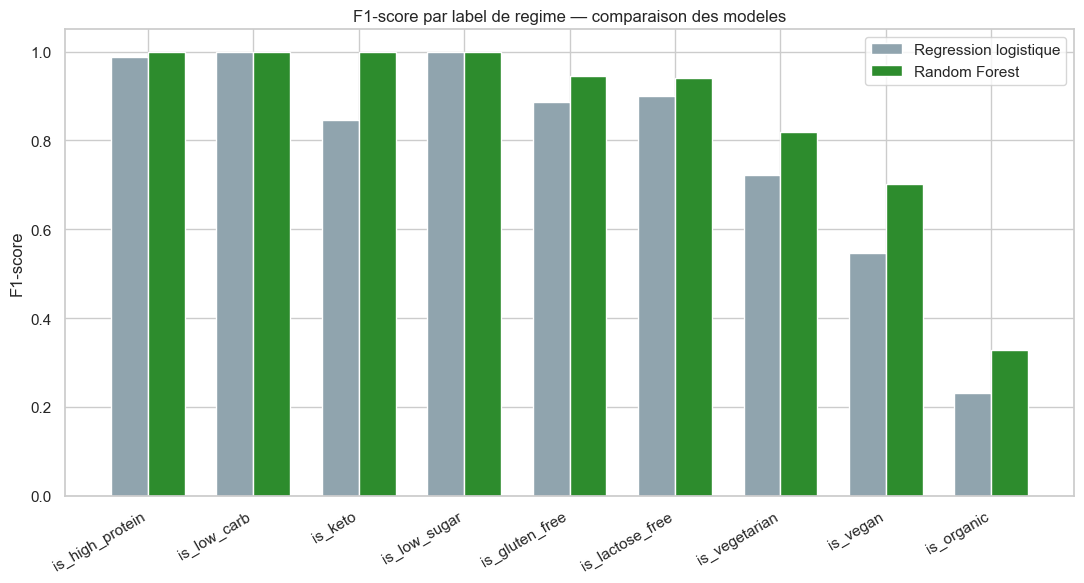

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(comparison))
width = 0.35

ax.bar(x - width/2, comparison['Regression logistique'], width, label='Regression logistique', color='#90a4ae')
ax.bar(x + width/2, comparison['Random Forest'], width, label='Random Forest', color='#2d8c2d')

ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=30, ha='right')
ax.set_ylabel('F1-score')
ax.set_title('F1-score par label de regime — comparaison des modeles')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 11. Analyse — flags "triviaux" vs flags "non triviaux"

On verifie l'hypothese formulee en introduction : les flags definis par des seuils nutritionnels (`is_keto`, `is_low_carb`, `is_high_protein`, `is_low_sugar`) devraient avoir un F1 proche de 1, car le modele dispose exactement des features necessaires pour les calculer. Les flags bases sur les ingredients/labels (`is_vegan`, `is_vegetarian`, `is_gluten_free`, `is_lactose_free`, `is_organic`) sont plus difficiles car l'information determinante n'est pas dans les features nutritionnelles.

In [13]:
nutrition_based = ['is_keto', 'is_low_carb', 'is_high_protein', 'is_low_sugar']
ingredient_based = ['is_vegan', 'is_vegetarian', 'is_gluten_free', 'is_lactose_free', 'is_organic']

rf_results_indexed = results_rf.set_index('label')

print("Flags definis par seuils nutritionnels (attendu : F1 ~ 1.0)")
print(rf_results_indexed.loc[nutrition_based, ['precision', 'recall', 'f1']].round(3).to_string())

print("\nFlags bases sur ingredients/labels (attendu : F1 < 1.0, prediction non triviale)")
print(rf_results_indexed.loc[ingredient_based, ['precision', 'recall', 'f1']].round(3).to_string())

print(f"\nF1 moyen — flags nutritionnels  : {rf_results_indexed.loc[nutrition_based, 'f1'].mean():.3f}")
print(f"F1 moyen — flags ingredients    : {rf_results_indexed.loc[ingredient_based, 'f1'].mean():.3f}")

Flags definis par seuils nutritionnels (attendu : F1 ~ 1.0)
                 precision  recall   f1
label                                  
is_keto                1.0     1.0  1.0
is_low_carb            1.0     1.0  1.0
is_high_protein        1.0     1.0  1.0
is_low_sugar           1.0     1.0  1.0

Flags bases sur ingredients/labels (attendu : F1 < 1.0, prediction non triviale)
                 precision  recall     f1
label                                    
is_vegan             0.695   0.710  0.703
is_vegetarian        0.851   0.789  0.819
is_gluten_free       0.986   0.908  0.945
is_lactose_free      0.984   0.901  0.941
is_organic           0.235   0.540  0.328

F1 moyen — flags nutritionnels  : 1.000
F1 moyen — flags ingredients    : 0.747


## 12. Importance des features (Random Forest)

Quels nutriments pesent le plus dans la prediction de chaque regime.

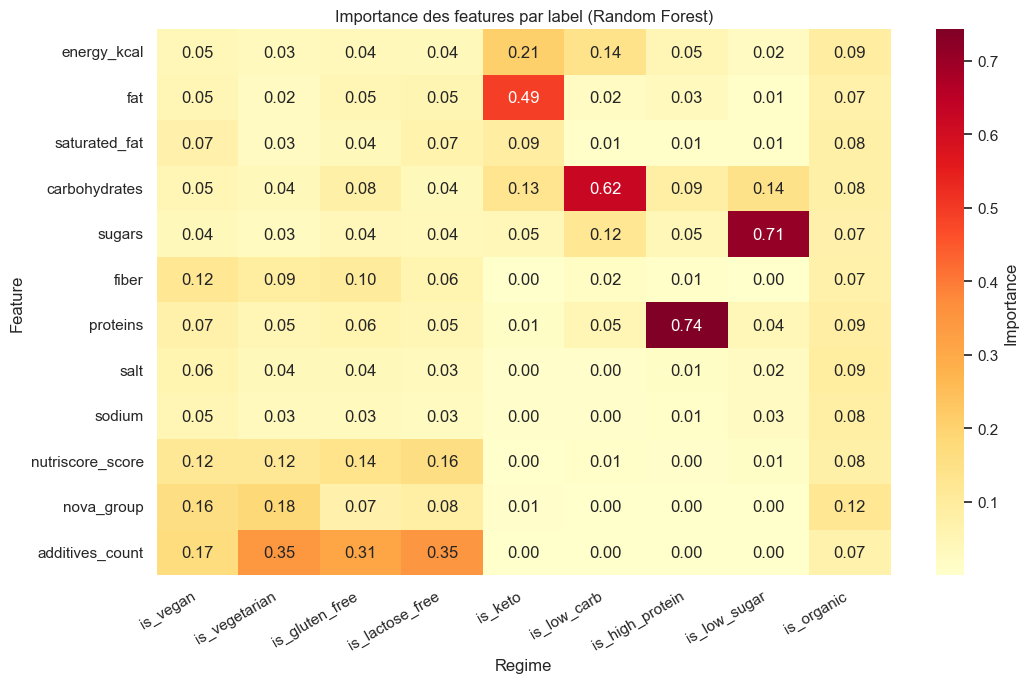

In [14]:
rf_estimators = rf_pipeline.named_steps['clf'].estimators_
feature_names_clean = [c.replace('nutrition.', '').replace('quality.', '').replace('meta.', '') for c in feature_cols]

importance_matrix = pd.DataFrame(
    {label: estimator.feature_importances_ for label, estimator in zip(label_names, rf_estimators)},
    index=feature_names_clean
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(importance_matrix, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Importance'})
ax.set_title("Importance des features par label (Random Forest)")
ax.set_xlabel('Regime')
ax.set_ylabel('Feature')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 13. Matrices de confusion par label (Random Forest)

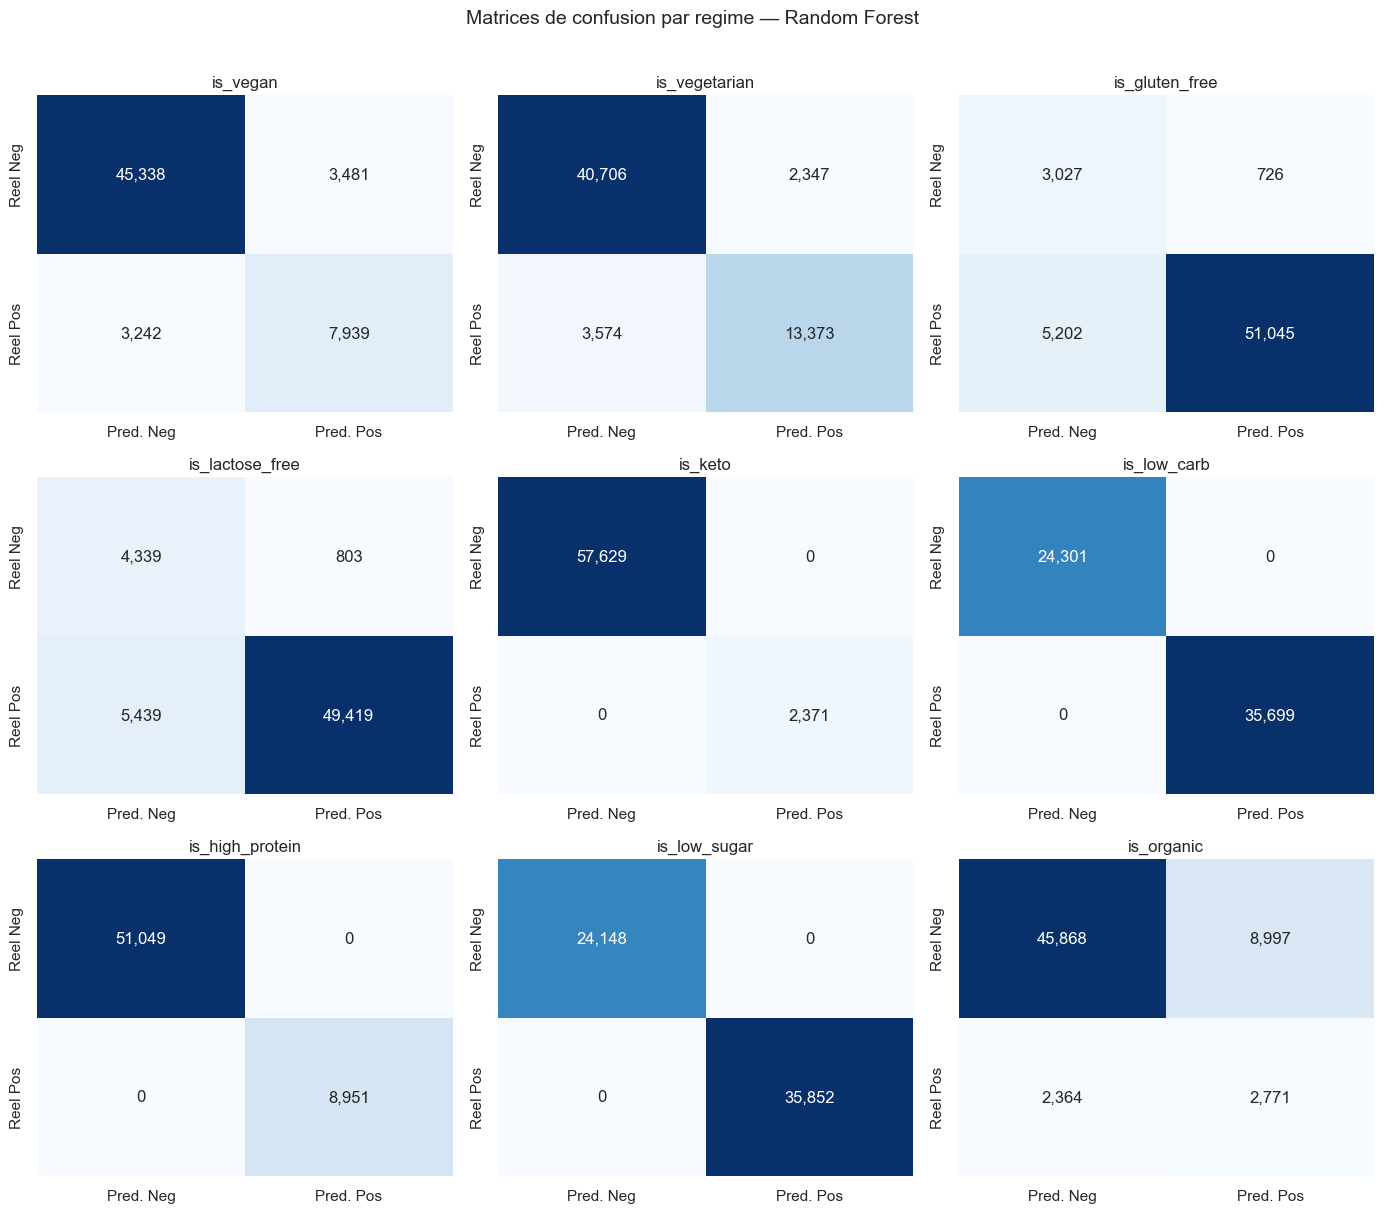

In [15]:
cms = multilabel_confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, (label, cm) in enumerate(zip(label_names, cms)):
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Pred. Neg', 'Pred. Pos'], yticklabels=['Reel Neg', 'Reel Pos'])
    axes[i].set_title(label)

plt.suptitle('Matrices de confusion par regime — Random Forest', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 14. Demonstration — prediction sur des produits du jeu de test

In [16]:
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=5, replace=False)

for idx in sample_idx:
    row_meta = meta_test.iloc[idx]
    true_labels = y_test.iloc[idx]
    pred_labels = y_pred_rf[idx]

    print(f"\n{'=' * 70}")
    print(f"Produit : {row_meta['product_name']} (code {row_meta['code']})")
    print(f"{'Regime':<20s} {'Reel':<8s} {'Predit':<8s} {'OK?'}")
    print('-' * 45)
    for j, label in enumerate(label_names):
        reel = 'Oui' if true_labels[label] == 1 else 'Non'
        predit = 'Oui' if pred_labels[j] == 1 else 'Non'
        ok = 'V' if true_labels[label] == pred_labels[j] else 'X'
        print(f"{label:<20s} {reel:<8s} {predit:<8s} {ok}")


Produit : Pistacchio (code 8003779000778.0)
Regime               Reel     Predit   OK?
---------------------------------------------
is_vegan             Non      Non      V
is_vegetarian        Non      Non      V
is_gluten_free       Oui      Oui      V
is_lactose_free      Oui      Oui      V
is_keto              Non      Non      V
is_low_carb          Non      Non      V
is_high_protein      Non      Non      V
is_low_sugar         Non      Non      V
is_organic           Non      Non      V

Produit : Bio-Aufstrich Tomate (code 746288548925.0)
Regime               Reel     Predit   OK?
---------------------------------------------
is_vegan             Non      Non      V
is_vegetarian        Non      Non      V
is_gluten_free       Oui      Oui      V
is_lactose_free      Oui      Oui      V
is_keto              Oui      Oui      V
is_low_carb          Oui      Oui      V
is_high_protein      Non      Non      V
is_low_sugar         Non      Non      V
is_organic           Oui  

## 15. Sauvegarde du modele

Le modele retenu (Random Forest, meilleur F1 sur la plupart des labels) est sauvegarde pour etre reutilise dans l'interface de demonstration Streamlit.

In [17]:
os.makedirs('../Models', exist_ok=True)

joblib.dump(rf_pipeline, '../Models/regime_classifier_rf.joblib')
joblib.dump(feature_cols, '../Models/regime_classifier_features.joblib')
joblib.dump(label_names, '../Models/regime_classifier_labels.joblib')

print("Modele sauvegarde dans ../Models/")
print("  - regime_classifier_rf.joblib       (pipeline imputer + RandomForest multi-label)")
print("  - regime_classifier_features.joblib (liste des colonnes features attendues)")
print("  - regime_classifier_labels.joblib   (liste des 9 labels de regime)")

Modele sauvegarde dans ../Models/
  - regime_classifier_rf.joblib       (pipeline imputer + RandomForest multi-label)
  - regime_classifier_features.joblib (liste des colonnes features attendues)
  - regime_classifier_labels.joblib   (liste des 9 labels de regime)


## 16. Conclusion

**Approche** : classifieur multi-label via `MultiOutputClassifier` (un estimateur binaire par regime), compare entre Regression Logistique (baseline lineaire) et Random Forest (non lineaire).

**Resultats attendus :**
- Les flags **nutritionnels** (`is_keto`, `is_low_carb`, `is_high_protein`, `is_low_sugar`) sont predits avec un F1 proche de 1 — confirmation que le pipeline (features -> regles -> ETL -> MongoDB -> modele) est coherent de bout en bout.
- Les flags **ingredients/labels** (`is_vegan`, `is_vegetarian`, `is_gluten_free`, `is_lactose_free`, `is_organic`) obtiennent un score plus faible, car l'information determinante (texte des ingredients, labels) n'est pas dans les features nutritionnelles utilisees. C'est un resultat attendu et honnete : le profil nutritionnel seul ne suffit pas a deviner si un produit est vegan ou bio.
- Le **Random Forest** surpasse generalement la regression logistique grace aux relations non lineaires (seuils) entre nutriments et regimes.

**Limites et ameliorations possibles :**
- Ajouter des features textuelles (TF-IDF sur `ingredients_text`, encodage de `main_category`) ameliorerait fortement les flags non-nutritionnels.
- Tester un `ClassifierChain` pour exploiter les dependances entre labels (ex: vegan implique vegetarien).
- Re-equilibrer davantage les classes rares (`is_organic`) avec du sur-echantillonnage (SMOTE).

**Prochaine etape** : integrer le modele sauvegarde (`../Models/regime_classifier_rf.joblib`) dans l'interface Streamlit pour permettre une prediction en direct sur un produit saisi par l'utilisateur.